In [1]:
import pandas as pd
print(pd.__version__)

2.3.3


## Telco Customer Churn — Keşifsel Veri Analizi (EDA)      

**Yazan:** Yusuf Eker
**Tarih:** Nisan 2026
**Dataset:** [Kaggle - blastchar/telco-customer-churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

print("Kütüphaneler yüklendi ✓")

Kütüphaneler yüklendi ✓


In [9]:
df = pd.read_csv("../data/telco_customer_churn.csv")
print(f"Veri boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")

# customerID sütununu çıkar (tahminsel değeri yok)
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

# TotalCharges sütunu string olarak geliyor, sayısala çevirildi.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(f"TotalCharges'ta {df['TotalCharges'].isna().sum()} eksik değer var (0 ile dolduruyoruz)")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Churn sütununu 0/1'e çeviriyoruz
df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)

df.head()

Veri boyutu: 7043 satır, 21 sütun
TotalCharges'ta 11 eksik değer var (0 ile dolduruyoruz)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_binary
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## Bulgu 1 — Genel Bakış

Dataset **7,043 müşteri** ve **20 feature** içeriyor (Churn hedef değişkeni dahil). `customerID` modellemeye dahil edilmiyor çünkü unique identifier. `TotalCharges` sütununda 11 satırda boş string var — bu sıfır tenure'lu yeni müşteriler, 0 ile doldurduk.

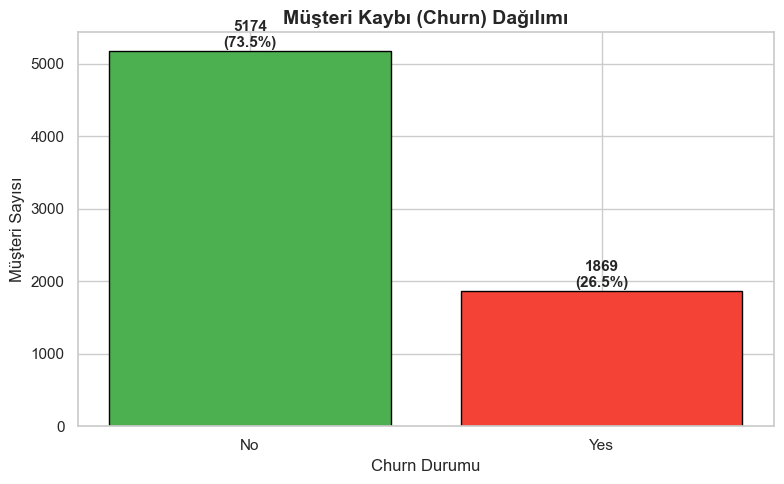


Churn oranı: %26.5


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
churn_counts = df["Churn"].value_counts()
colors = ["#4CAF50", "#F44336"]  # yeşil = No, kırmızı = Yes

bars = ax.bar(churn_counts.index, churn_counts.values, color=colors, edgecolor="black")
ax.set_title("Müşteri Kaybı (Churn) Dağılımı", fontsize=14, fontweight="bold")
ax.set_xlabel("Churn Durumu")
ax.set_ylabel("Müşteri Sayısı")

# Üstüne yüzde ekle
total = churn_counts.sum()
for bar, count in zip(bars, churn_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f"{count}\n({pct:.1f}%)", ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/eda_churn_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nChurn oranı: %{df['Churn_binary'].mean()*100:.1f}")

## Bulgu 2 — Sınıf Dengesizliği

Müşterilerin yaklaşık **%26.5'i churn etmiş** (hizmetten ayrılmış), **%73.5'i kalmış**. Bu orta dereceli bir sınıf dengesizliği yaratıyor — modeller "hep kalacak" diyerek %73 accuracy yakalayabilir ama bu yanıltıcı olur. Bu yüzden değerlendirmede **F1 skoru** ve **ROC-AUC** gibi metrikler daha güvenilir.

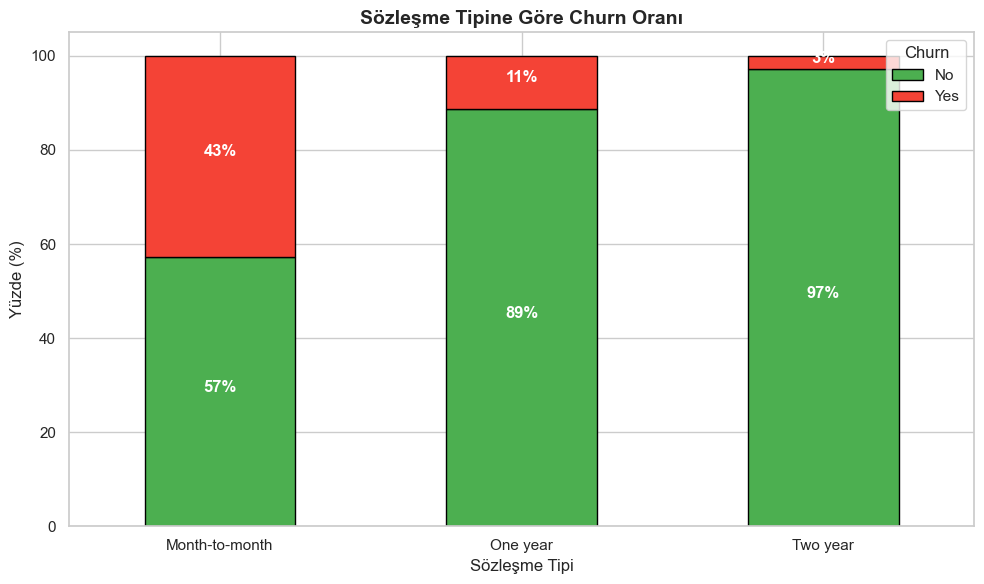

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

contract_churn.plot(kind="bar", stacked=True, ax=ax, color=["#4CAF50", "#F44336"], edgecolor="black")
ax.set_title("Sözleşme Tipine Göre Churn Oranı", fontsize=14, fontweight="bold")
ax.set_xlabel("Sözleşme Tipi")
ax.set_ylabel("Yüzde (%)")
ax.legend(title="Churn", loc="upper right")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Yüzdeleri bar'ların ortasına yaz
for i, (_, row) in enumerate(contract_churn.iterrows()):
    ax.text(i, row["No"]/2, f"{row['No']:.0f}%", ha="center", color="white", fontweight="bold")
    ax.text(i, row["No"] + row["Yes"]/2, f"{row['Yes']:.0f}%", ha="center", color="white", fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/eda_contract_churn.png", dpi=120, bbox_inches="tight")
plt.show()

## Bulgu 3 — Sözleşme Tipi En Güçlü Öngörücü

Churn oranında sözleşme tipine göre dramatik bir fark var:
- **Month-to-month** müşterilerinin **yaklaşık %42'si** churn etmiş
- **One year** sözleşmelilerde bu oran **%11**'e düşüyor
- **Two year** sözleşmelilerde neredeyse **sıfıra** iniyor (%3)

Bu bulgu pazarlama açısından kritik: müşterileri daha uzun süreli sözleşmelere teşvik etmek churn riskini belirgin biçimde azaltıyor.

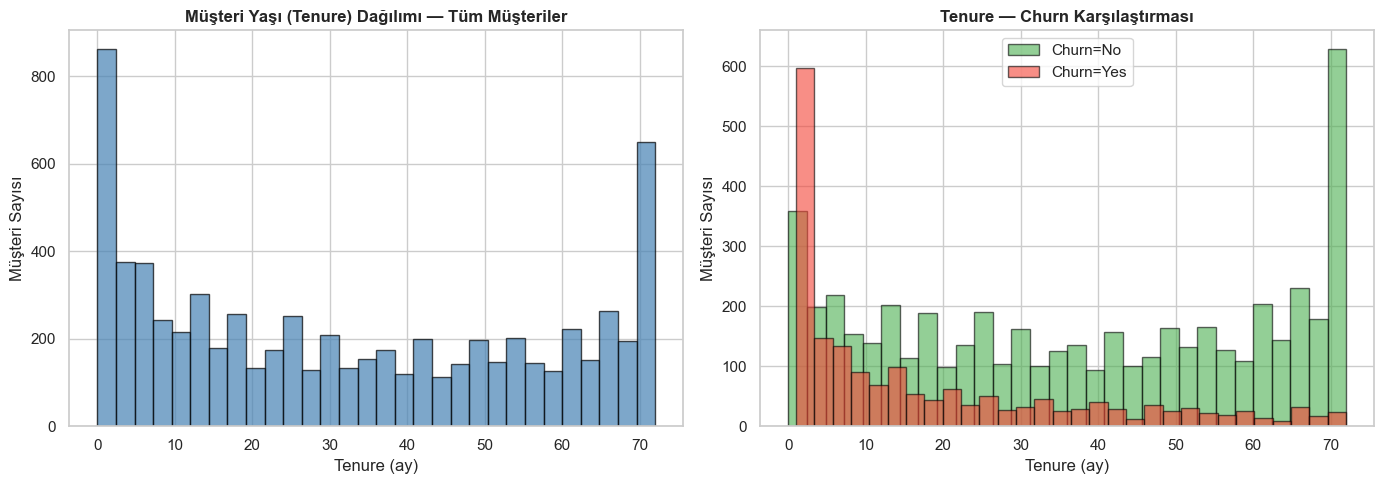


Churn eden müşterilerin ortalama tenure'u: 18.0 ay
Kalan müşterilerin ortalama tenure'u: 37.6 ay


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: tüm müşterilerin tenure dağılımı
axes[0].hist(df["tenure"], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
axes[0].set_title("Müşteri Yaşı (Tenure) Dağılımı — Tüm Müşteriler", fontweight="bold")
axes[0].set_xlabel("Tenure (ay)")
axes[0].set_ylabel("Müşteri Sayısı")

# Sağ: churn'e göre tenure karşılaştırması
for label, color, alpha in [("No", "#4CAF50", 0.6), ("Yes", "#F44336", 0.6)]:
    axes[1].hist(df[df["Churn"] == label]["tenure"], bins=30,
                  color=color, edgecolor="black", alpha=alpha, label=f"Churn={label}")

axes[1].set_title("Tenure — Churn Karşılaştırması", fontweight="bold")
axes[1].set_xlabel("Tenure (ay)")
axes[1].set_ylabel("Müşteri Sayısı")
axes[1].legend()

plt.tight_layout()
plt.savefig("../reports/figures/eda_tenure.png", dpi=120, bbox_inches="tight")
plt.show()

# İstatistik
print(f"\nChurn eden müşterilerin ortalama tenure'u: {df[df['Churn']=='Yes']['tenure'].mean():.1f} ay")
print(f"Kalan müşterilerin ortalama tenure'u: {df[df['Churn']=='No']['tenure'].mean():.1f} ay")

## Bulgu 4 — Yeni Müşteriler Daha Çok Churn Ediyor

Churn eden müşterilerin yaklaşık **%50'si ilk 10 ay içinde** ayrılıyor. Kalan müşterilerin dağılımı daha düzgün — uzun süre kalan müşteriler kalıcı olma eğiliminde.

- Churn edenlerin ortalama tenure: **~18 ay**
- Kalan müşterilerin ortalama tenure: **~38 ay**

Bu, müşteri kazanma aşamasında verilen ilk deneyimin kritik olduğunu gösteriyor. İlk yıl boyunca özellikle ilgi göstermek churn'ü azaltabilir.

C:\Users\Yusuf\AppData\Local\Temp\ipykernel_17380\1838078436.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=axes[0],
C:\Users\Yusuf\AppData\Local\Temp\ipykernel_17380\1838078436.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="TotalCharges", data=df, ax=axes[1],


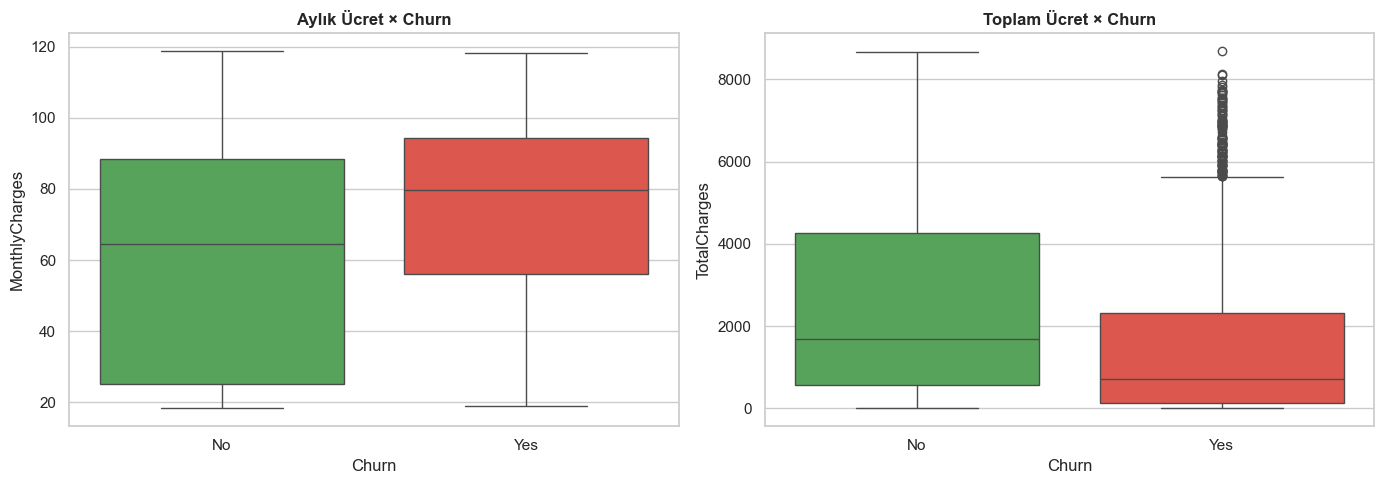


Churn eden müşterilerin ortalama MonthlyCharges: $74.44
Kalan müşterilerin ortalama MonthlyCharges: $61.27


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly Charges
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=axes[0],
             palette={"No": "#4CAF50", "Yes": "#F44336"})
axes[0].set_title("Aylık Ücret × Churn", fontweight="bold")

# Total Charges
sns.boxplot(x="Churn", y="TotalCharges", data=df, ax=axes[1],
             palette={"No": "#4CAF50", "Yes": "#F44336"})
axes[1].set_title("Toplam Ücret × Churn", fontweight="bold")

plt.tight_layout()
plt.savefig("../reports/figures/eda_charges.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nChurn eden müşterilerin ortalama MonthlyCharges: ${df[df['Churn']=='Yes']['MonthlyCharges'].mean():.2f}")
print(f"Kalan müşterilerin ortalama MonthlyCharges: ${df[df['Churn']=='No']['MonthlyCharges'].mean():.2f}")

## Bulgu 5 — Yüksek Ücret + Düşük Tenure = Yüksek Risk

- **Aylık ücreti yüksek olan müşteriler** ortalamada daha çok churn ediyor (median yaklaşık \$80 vs \$65)
- **Toplam ücretleri düşük olan müşteriler** daha çok churn ediyor — çünkü yeniler, henüz uzun süre hizmet almamışlar

Bu iki değişkenin birlikte kullanımı (yüksek aylık + düşük toplam = yeni + pahalı tarife) en riskli segmenti işaret ediyor.

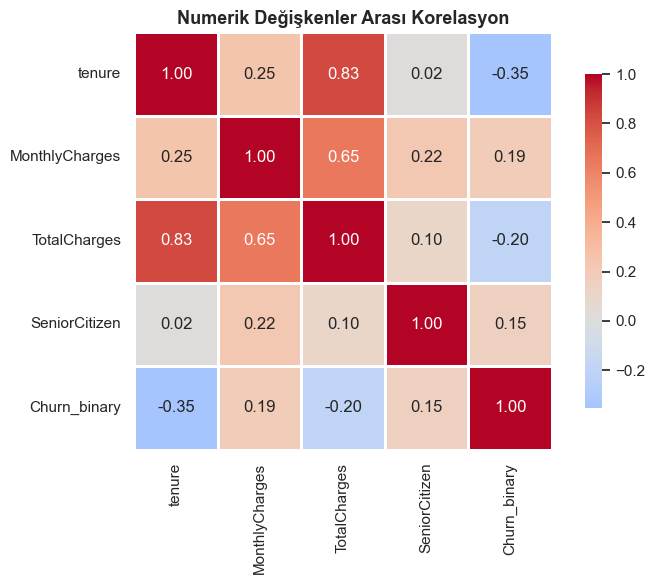

In [14]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen", "Churn_binary"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, ax=ax,
             fmt=".2f", square=True, linewidths=1, cbar_kws={"shrink": 0.8})
ax.set_title("Numerik Değişkenler Arası Korelasyon", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("../reports/figures/eda_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

## Bulgu 6 — Korelasyonlar

- **tenure ↔ Churn_binary = -0.35** (negatif, orta) — müşteri yaşlandıkça churn riski azalıyor
- **TotalCharges ↔ tenure = 0.83** (pozitif, güçlü) — beklendiği gibi, uzun süre kalan çok öder
- **MonthlyCharges ↔ Churn_binary = 0.19** (pozitif, zayıf-orta) — pahalı paket riski artırıyor ama güçlü predictor değil tek başına



## 📌 Özet Bulgular

| # | Bulgu | İş Değeri |
|---|-------|-----------|
| 1 | Sınıf dengesizliği %26.5 churn | F1/AUC kullanılmalı, accuracy yanıltıcı |
| 2 | Month-to-month sözleşme = yüksek risk (%42) | Uzun dönem sözleşmeye teşvik stratejik öneme sahip |
| 3 | İlk 10 ay kritik — churn burada yoğun | Onboarding deneyimine yatırım yapılmalı |
| 4 | Yüksek MonthlyCharges + düşük tenure = en riskli segment | Yeni müşterilere pahalı paket satıldığında ekstra özen |
| 5 | tenure en güçlü numerik öngörücü | Modellemede kritik feature |
| 6 | TotalCharges tenure ile çok korele | Feature seçiminde birinin kaldırılması düşünülebilir (sklearn Pipeline'da zaten StandardScaler ile normalize ediliyor) |

**Sonuç:** Bulgular modelin verdiği SHAP çıktılarıyla tutarlı (`reports/figures/shap_summary.png`). EDA'dan çıkan risk faktörleri ve modelin öğrendiği risk faktörleri birebir örtüşüyor: tenure, Contract, MonthlyCharges, InternetService tipi.

In [15]:
print("EDA tamamlandı ✓")
print("\nÜretilen görseller:")
import os
for f in sorted(os.listdir("../reports/figures")):
    if f.startswith("eda_"):
        size = os.path.getsize(f"../reports/figures/{f}") / 1024
        print(f"  - {f} ({size:.1f} KB)")

EDA tamamlandı ✓

Üretilen görseller:
  - eda_charges.png (34.0 KB)
  - eda_churn_distribution.png (26.0 KB)
  - eda_contract_churn.png (33.8 KB)
  - eda_correlation.png (60.3 KB)
  - eda_tenure.png (43.3 KB)
